In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

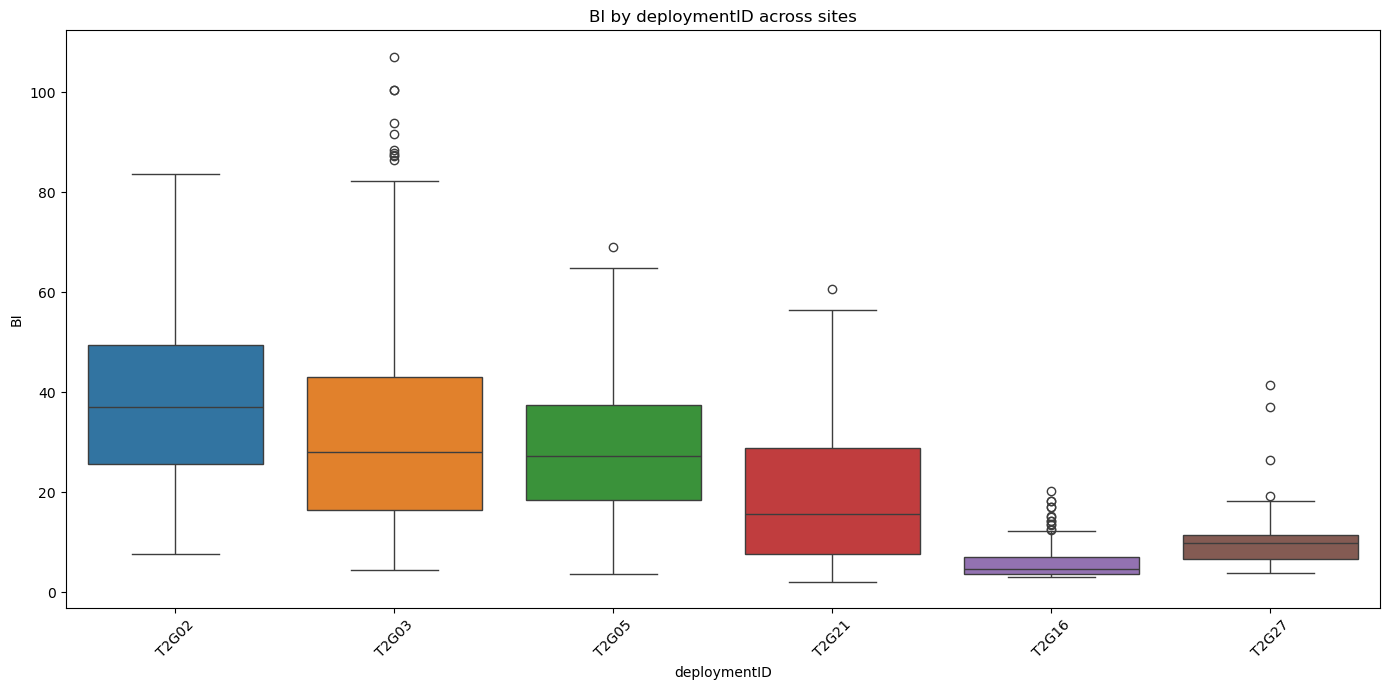

In [10]:
files = [
    'indices_T2G02.csv',
    'indices_T2G03.csv',
    'indices_T2G05.csv',
    'indices_T2G21.csv',
    'indices_T2G16.csv',
    'indices_T2G27.csv',
]

dfs = []
for fname in files:
    tmp = pd.read_csv(f'../data/output_t2/acoustic_indices/{fname}')
    tmp['site'] = fname.replace('indices_', '').replace('.csv', '')
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)

# Plotting BI by deploymentID across sites
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_all, x='site', y='BI', hue='site')
plt.xticks(rotation=45)
plt.xlabel('deploymentID')
plt.ylabel('BI')
plt.title('BI by deploymentID across sites')
plt.tight_layout()
plt.show()

# Checking indices

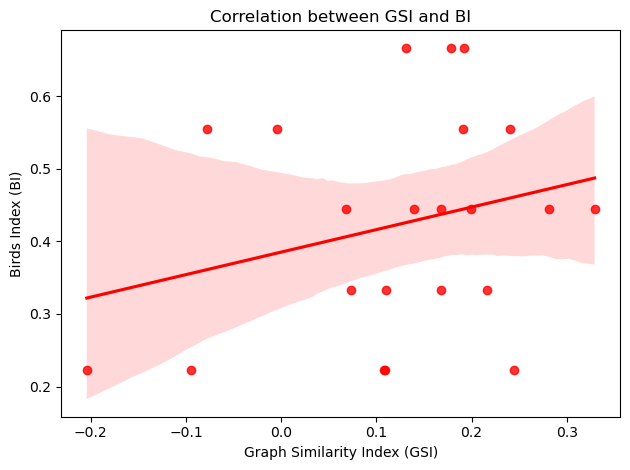

In [24]:
df_gsi = pd.read_csv('../data/output_t1/similarity_index/graph_similarity_index.csv')
df_bi = pd.read_csv('../data/output_t1/birds_index/avifauna_interior_bosque.csv')
df_idx = df_gsi.merge(df_bi, on='deploymentID', how='inner')

# plot regression to check correlation between indices
sns.regplot(data=df_idx, x='graphSimilarityIndex', y='indice', scatter=True, color='red')
plt.title('Correlation between GSI and BI')
plt.xlabel('Graph Similarity Index (GSI)')
plt.ylabel('Birds Index (BI)')
plt.tight_layout()
plt.show()

In [22]:
import statsmodels.api as sm

# 3. Regresión Lineal Detallada
X = sm.add_constant(df_idx['graphSimilarityIndex']) # añade intercepto
model = sm.OLS(df_idx['indice'], X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 indice   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.464
Date:                Wed, 13 May 2026   Prob (F-statistic):              0.240
Time:                        20:11:26   Log-Likelihood:                 11.525
No. Observations:                  22   AIC:                            -19.05
Df Residuals:                      20   BIC:                            -16.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3853      0.045      8.481      0.000       0.291       0.480
graphSimilarityIndex     0.3101      0.256      1.210      0.240      -0.225       0.845
==============================================================================
Omnibus:                        2.185   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.335   Jarque-Bera (JB):                1.222
Skew:                           0.230   Prob(JB):                        0.543
Kurtosis:                       1.941   Cond. No.                         8.13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Test on SONABIO data

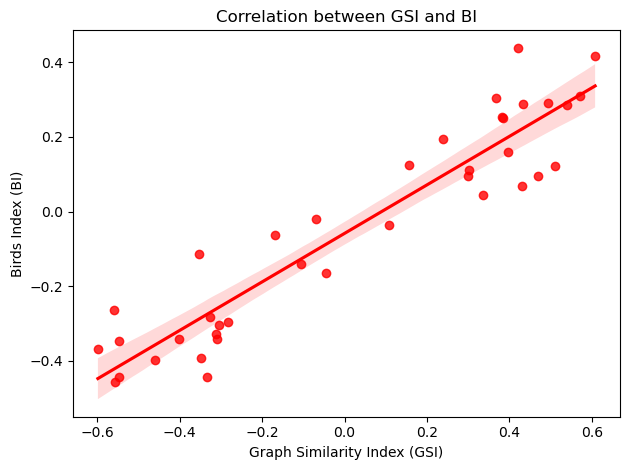

In [26]:
df_gsi = pd.read_csv('../../../2023_SONABIO/Análisis/output/index/index_graph_cosine_t1.csv')
df_bi = pd.read_csv('../../../2023_SONABIO/Análisis/output/index/index_birdnet_cosine_t1.csv')
df_bi.rename(columns={'BAI': 'BI'}, inplace=True)  
df_idx = df_gsi.merge(df_bi, on='site', how='inner')

# plot regression to check correlation between indices
sns.regplot(data=df_idx, x='BAI', y='BI', scatter=True, color='red')
plt.title('Correlation between GSI and BI')
plt.xlabel('Graph Similarity Index (GSI)')
plt.ylabel('Birds Index (BI)')
plt.tight_layout()
plt.show()

In [28]:
# 3. Regresión Lineal Detallada
X = sm.add_constant(df_idx['BAI']) # añade intercepto
model = sm.OLS(df_idx['BI'], X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     BI   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     270.2
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.58e-18
Time:                        20:20:57   Log-Likelihood:                 35.621
No. Observations:                  38   AIC:                            -67.24
Df Residuals:                      36   BIC:                            -63.97
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0586      0.016     -3.705      0.001      -0.091      -0.027
BAI            0.6507      0.040     16.438      0.000       0.570       0.731
==============================================================================
Omnibus:                        0.637   Durbin-Watson:                   2.363
Prob(Omnibus):                  0.727   Jarque-Bera (JB):                0.747
Skew:                           0.224   Prob(JB):                        0.688
Kurtosis:                       2.479   Cond. No.                         2.51
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""